In [23]:
from uncertainties import ufloat
from uncertainties import unumpy as unp
import numpy as np
import matplotlib.pyplot as plt
import scipy
import matplotlib
from matplotlib.ticker import LogLocator
from uncertainties.umath import log

In [24]:
Länge_Fehler = 1# in mm
Länge = [(980,67, 42.5),(960,46,22),(950,35.5,12.5)]   # (oben, oben_kugel, unten_kugel) in mm

Ls_oben = [ufloat(x[0],Länge_Fehler) - ufloat(x[1],Länge_Fehler) for x in Länge] # Länge bis oben an die Kugel in mm
Ls_unten = [ufloat(x[0],Länge_Fehler) - ufloat(x[2],Länge_Fehler) for x in Länge] # Länge bis oben an die Kugel in mm


Ls_oben

[913.0+/-1.4142135623730951,
 914.0+/-1.4142135623730951,
 914.5+/-1.4142135623730951]

In [25]:
def Fehler_des_Mittelwerts(array, n = 3):
    return np.std(array,ddof=1) / np.sqrt(n)

def nom(array):
    return [x.nominal_value for x in array]

Fehler_des_Mittelwerts(nom(Ls_unten))

Fehler_L_oben = np.sqrt(Fehler_des_Mittelwerts(nom(Ls_oben)) ** 2 + np.sqrt(Länge_Fehler + Länge_Fehler)**2)
Fehler_L_oben
L_oben = ufloat(np.average(nom(Ls_oben)),Fehler_L_oben)


L_unten = ufloat(np.average(nom(Ls_unten)),np.sqrt(Fehler_des_Mittelwerts(nom(Ls_unten)) ** 2 + np.sqrt(Länge_Fehler + Länge_Fehler)**2))


L = ((L_oben + L_unten) / 2) / 1000 #- 0.001
print(L)

0.9257+/-0.0010


In [26]:
def printu(u, digits=2):
    print(("{:." + str(digits) + "e}").format(u).replace("/","").replace("(","").replace(")","").replace("e-0","e-"))

In [27]:

# Bestimmen von detla t
Fehler_Zeitmessung = 0.2
Ts = [38.56,38.7,38.62,38.62,38.61]

T = (ufloat(np.average(Ts),Fehler_des_Mittelwerts(Ts, n=5)) + ufloat(0, Fehler_Zeitmessung)) / 20
           
print(T)

1.931+/-0.010


In [28]:

delta_t = T.std_dev * 20 # delta kleines t
n = 2 * delta_t / T.nominal_value * L.nominal_value / (0.3 * L.std_dev)
print(n)



626.0458011140737


In [29]:
Durchmesser_Kugel = ufloat(24.0,0.05) # in mm
Durchmesser_Kugel /= 1000 # in m



In [30]:
# Lange Messung
Reaktionszeit= 0.2
T_ges = ufloat(23 * 60 + 09.72,Reaktionszeit)
N = 1440 / 2

Ablesegenauigkeit = 1
Amplitudenmessung = [(0,18.2,0),
             (62,17.2,60.3),
             (110,16.3,45.5),
             (162,15.4,50.91),
             (212,14.9,48.35),
             (258,14.4,43.73),
             (306,13.8,46.54),
             (362,13.3,0),
             (450,12.4,139.23),
             (500,12.0,48.33),
             (546,11.6,44.13),
             (612,11.1,63.75),
             (670,10.7,55.73),
             (702,10.5,30.90),
             (760,10.1,55.92),
             (806,9.8,44.82),
             (860,9.5,51.99),
             (910,9.2,47.99),
             (970,8.9,57.98),
             (1002,8.8,30.88),
             (1050,8.6,46.13),
             (1100,8.3,48.11),
             (1148,8.1,46.48),
             (1202,7.9,52.00),
             (1250,7.7,0),
             (1298,7.5,93.14),
             (1348,7.3,48.11),
             (1400,7.1,50.39)          
            ] # (Anzahl Nulldurchgänge,Auslenknug, Delta Zeit)

print(T_ges / N)

print(len(Amplitudenmessung))

1.93017+/-0.00028
28


In [31]:

N_Nulldurchgänge,Amplitude_waagrecht, Delta_T = zip(*Amplitudenmessung)
Amplitude_waagrecht = np.array(Amplitude_waagrecht) / 100
Delta_T = np.array(Delta_T)

Delta_Nulldurchgänge = [0]+ [(N_Nulldurchgänge[x+1] - N_Nulldurchgänge[x]) / 2 for x in range(len(Amplitudenmessung) - 1)]
#print("\n".join([str(x) for x in list(zip(Delta_T / T.nominal_value,Delta_Nulldurchgänge))]))
N_Perioden = np.array(N_Nulldurchgänge) / 2
print(sum(Delta_T))

1351.3400000000001


In [32]:
def Exponential_Function(t, a,delta):
    return a * np.e ** (delta * t)
    

In [46]:


Höhe_Amplitudenmessung = ufloat(92,2) / 1000 # m
Unterkante_Kugel = ufloat(13,1) / 1000 # m 
Aufhängung = ufloat(950,1) / 1000
Messhöhe = Aufhängung - Höhe_Amplitudenmessung 
Amplitude = unp.arctan(unp.uarray(Amplitude_waagrecht,[0.002] * len(Amplitude_waagrecht)) / Messhöhe)

#print(Amplitude)
(a_fit,delta_fit), cov = scipy.optimize.curve_fit(Exponential_Function, N_Perioden, unp.nominal_values(Amplitude), sigma=[0.001] * len(Amplitude), absolute_sigma=True,bounds=([0,-0.1],[1,0.1]))
#print(a_fit, delta_fit)
error = np.sqrt(np.diag(cov))
d_a_fit, d_delta_fit = error
print(delta_fit)
printu(Messhöhe)

#print(error)

-0.0013516710010562207
8.58+-0.02e-1


In [34]:
a_0 = Amplitude[0]
print(a_0)
times = [] 
for i in range(len(Delta_T)-1):
    times.append(sum(Delta_T[0:i+2]))
    #print(sum(Delta_T[0:i+2]))
    
#print(times)
T_Amplitudenmessung = times
Delta_Formel = - unp.log(Amplitude[1:] / a_0)/T_Amplitudenmessung
#print(Delta_Formel)
Delta_Formel = sum(Delta_Formel) / len(Delta_Formel)
print(Delta_Formel)


0.2090+/-0.0023
0.000817+/-0.000031


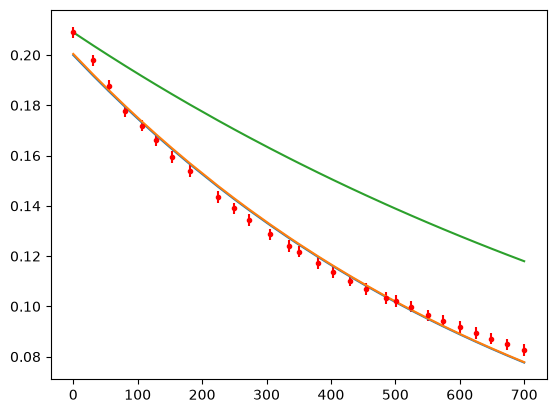

In [35]:
plt.errorbar(N_Perioden,nom(Amplitude),unp.std_devs(Amplitude), fmt="r.")
plt.plot(N_Perioden, Exponential_Function(N_Perioden, a_fit,delta_fit))
plt.plot(N_Perioden, Exponential_Function(N_Perioden, a_fit+d_a_fit,delta_fit))
plt.plot(N_Perioden, Exponential_Function(N_Perioden,a_0.nominal_value,-Delta_Formel.nominal_value))


7.00+-0.85e-4


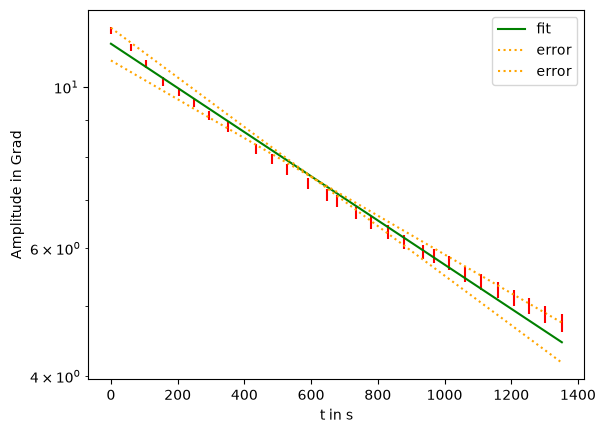

In [36]:
Amplitude_log = unp.log(unp.uarray(nom(Amplitude),unp.std_devs(Amplitude)))
Amplitude_log

Zeiten_Ampllitude = N_Perioden * T.nominal_value
def linear(x,m,b):
    return m * x + b
    
(m_fit,b_fit), cov = scipy.optimize.curve_fit(linear, Zeiten_Ampllitude, unp.nominal_values(Amplitude_log), sigma=unp.std_devs(Amplitude_log) *10 , absolute_sigma=True)
error = np.sqrt(np.diag(cov))
d_m_fit, d_b_fit = error
b_fit = unp.exp([ufloat(b_fit,d_b_fit)])[0]
d_b_fit = b_fit.std_dev
b_fit = b_fit.nominal_value
plt.semilogy(0,12)
plt.ylabel("Amplitude in Grad")

plt.errorbar(Zeiten_Ampllitude, unp.nominal_values(Amplitude)/ (2 * np.pi) * 360 , unp.std_devs(Amplitude) / (2 * np.pi) * 360 ,fmt="r,")
plt.plot(Zeiten_Ampllitude, Exponential_Function(Zeiten_Ampllitude,b_fit,m_fit)/ (2 * np.pi) * 360 , label="fit", color="green")
plt.plot(Zeiten_Ampllitude, Exponential_Function(Zeiten_Ampllitude,b_fit-d_b_fit,(m_fit + d_m_fit))/ (2 * np.pi) * 360 , label="error",color="orange",linestyle="dotted")
plt.plot(Zeiten_Ampllitude , Exponential_Function(Zeiten_Ampllitude,b_fit+d_b_fit,(m_fit - d_m_fit))/ (2 * np.pi) * 360 , label="error",color="orange",linestyle="dotted")
plt.xlabel("t in s")
ax = plt.gca()
#ax.yaxis.set_major_locator(LogLocator(base=10, numticks=150))
#ax.yaxis.set_minor_locator(LogLocator(base=10, subs=range(2, 100)))
plt.legend()
plt.savefig("Plot1.svg")

delta = -ufloat(m_fit, d_m_fit)
printu(delta)


# Erste Rechnung für g

In [56]:
Radius_Kugel = Durchmesser_Kugel / 2
T = T_ges / N
rho_F = 7.86 * 1000 # 7.874 * 1000 # kg/m^3
rho_L =  1.2041 # kg / m^3
r_Faden = 0.1 * 10**(-3) # m
V_Kugel = 4/3 * np.pi * Radius_Kugel ** 3
m_Kugel = rho_F * V_Kugel
m_Faden = (L_oben / 1000) * rho_F * np.pi * r_Faden ** 2

printu(m_Kugel)
printu(m_Faden,digits=3)
print(T)
print(L)
printu(L_oben)

5.69+-0.04e-2
2.257+-0.004e-4
1.93017+/-0.00028
0.9257+/-0.0010
9.14+-0.01e+02


In [51]:
Korrektur_auftrieb = 2/5 * Radius_Kugel**2 / L**2 + rho_L/rho_F - 1/6 * m_Faden /m_Kugel


g_1 = (4 * np.pi**2 * L)/T**2 *(1+ Korrektur_auftrieb)
print(g_1)
print(Korrektur_auftrieb)




9.806+/-0.011
-0.000441+/-0.000005



# Zweite Rechnung für g


In [52]:
omega_0 = 2 * np.pi / T
print(omega_0)

# phi_0 berechnen

Auslenkung_max =  ufloat(0.182,0.001)
tan_phi = Auslenkung_max / Messhöhe
phi_0 = unp.arctan([tan_phi])[0] 
print(phi_0 / (2 * np.pi) * 360)

Korrektur_delta = delta**2 / omega_0**2
Korrektur_phi_0 = phi_0**2 / 8
printu(Korrektur_delta)
printu(Korrektur_phi_0)

3.2553+/-0.0005
11.98+/-0.07
4.62+-1.13e-8
5.46+-0.06e-3


In [53]:
g_2 = (4 * np.pi**2 * L)/T**2 *(1+ Korrektur_auftrieb + Korrektur_delta + Korrektur_phi_0)
print(g_2)


9.859+/-0.011


In [54]:
# Test der Korrektur entlang der Amplitude
print(phi_0 / (2 * np.pi) * 360,delta)
print(b_fit)
phi_0 = b_fit
def amplitude(t):    
    return Exponential_Function(t,phi_0,-delta)

def korrektur(amplitude):
    return amplitude**2 / 8
korrektur_amplitude = np.average(korrektur(amplitude(np.arange(0,T_ges.nominal_value))))
print("korrektur_amplitude" )
printu(korrektur_amplitude)
g_3 = (4 * np.pi**2 * L)/T**2 *(1+Korrektur_auftrieb + Korrektur_delta + korrektur_amplitude)
print(g_3)
printu(korrektur_amplitude)
printu(Korrektur_delta)

#plt.plot(x,amplitude(x) / (2 * np.pi) * 360)

11.98+/-0.07 0.00070+/-0.00009
0.20020284092719498
korrektur_amplitude
2.21+-0.18e-3
9.827+/-0.011
2.21+-0.18e-3
4.62+-1.13e-8


In [55]:
# unterschied zwischen T am Anfang und am Ende:

print(korrektur(amplitude(0)), korrektur(amplitude(T_ges)))

0.005010147189414968+/-0 0.00072+/-0.00017


In [43]:

printu(g_1,digits=3)
printu(g_2,digits=3)
printu(g_3,digits=3)

g_4 = (4 * np.pi**2 * L)/T**2 *(1+Korrektur_auftrieb + Korrektur_delta)
printu(g_4,digits=3)


9.806+-0.011e+00
9.859+-0.011e+00
9.827+-0.011e+00
9.806+-0.011e+00


In [44]:

g_r = ufloat(9.80984, 2* 10**(-5))
def standardized_mean_difference(u1,u2):
    return (u1.nominal_value - u2.nominal_value)/(np.sqrt(u1.std_dev**2 + u2.std_dev**2)).__round__(2)

print(standardized_mean_difference(g_1,g_r).__round__(2))
print(standardized_mean_difference(g_2,g_r).__round__(2))
print(standardized_mean_difference(g_3,g_r).__round__(2))

-0.43
4.93
1.74
